# Abalone Health Analysis

This notebook explores the Abalone dataset with a mix of data cleaning, exploratory analysis, regression, classification, and clustering. The target variable `Spots` is used here as a practical health proxy, while `Sex` is used for classification and cluster comparison.

## Goals

- inspect data quality issues and missing values
- clean invalid category values and cap outliers with the IQR rule
- visualise the dataset and save the generated charts
- predict `Spots` with LASSO regression split by sex
- classify `Sex` with a decision tree and logistic regression
- compare unsupervised clusters against the original sex labels


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'Abalone Data Set [2874].xlsx'
IMAGES_DIR = BASE_DIR / 'images'
IMAGES_DIR.mkdir(exist_ok=True)

def save_plot(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / filename, dpi=200, bbox_inches='tight')

DATA_PATH, IMAGES_DIR


(WindowsPath('C:/Users/sgom0/Desktop/Job search/abalone/Abalone Data Set [2874].xlsx'),
 WindowsPath('C:/Users/sgom0/Desktop/Job search/abalone/images'))

## Load Data

In [2]:
df = pd.read_excel(DATA_PATH)
print('Shape:', df.shape)
df.head()


Shape: (2097, 8)


,Sex,Length(mm),Diameter(mm),Height(mm),WholeWeight(g),ShuckedWeight(g),SellWeight(g),Spots
0,M,0.455,0.365,0.095,0.5140,0.2245,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.055,7


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2097 entries, 0 to 2096
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sex               2097 non-null   str    
 1   Length(mm)        2095 non-null   float64
 2   Diameter(mm)      2096 non-null   float64
 3   Height(mm)        2096 non-null   float64
 4   WholeWeight(g)    2096 non-null   float64
 5   ShuckedWeight(g)  2095 non-null   float64
 6   SellWeight(g)     2096 non-null   float64
 7   Spots             2097 non-null   int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 131.2 KB


## Data Quality And Preprocessing

In [4]:
missing_summary = df.isnull().sum().rename('missing_values').to_frame()
missing_summary


,missing_values
Sex,0
Length(mm),2
Diameter(mm),1
Height(mm),1
WholeWeight(g),1
ShuckedWeight(g),2
SellWeight(g),1
Spots,0


In [5]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

invalid_sex_count = (~df['Sex'].isin(['M', 'F', 'I'])).sum()
df = df[df['Sex'].isin(['M', 'F', 'I'])].copy()
df['Sex'] = df['Sex'].astype(str)

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

for col in num_cols:
    df[col] = np.where(df[col] > upper_bound[col], upper_bound[col], df[col])
    df[col] = np.where(df[col] < lower_bound[col], lower_bound[col], df[col])

print('Invalid sex values removed:', int(invalid_sex_count))
print('Cleaned shape:', df.shape)
df.head()


Invalid sex values removed: 2
Cleaned shape: (2095, 8)


,Sex,Length(mm),Diameter(mm),Height(mm),WholeWeight(g),ShuckedWeight(g),SellWeight(g),Spots
0,M,0.455,0.365,0.095,0.5140,0.2245,0.150,15.0
1,M,0.350,0.265,0.090,0.2255,0.0995,0.070,7.0
2,F,0.530,0.420,0.135,0.6770,0.2565,0.210,9.0
3,M,0.440,0.365,0.125,0.5160,0.2155,0.155,10.0
4,I,0.330,0.255,0.080,0.2050,0.0895,0.055,7.0


## Exploratory Data Analysis

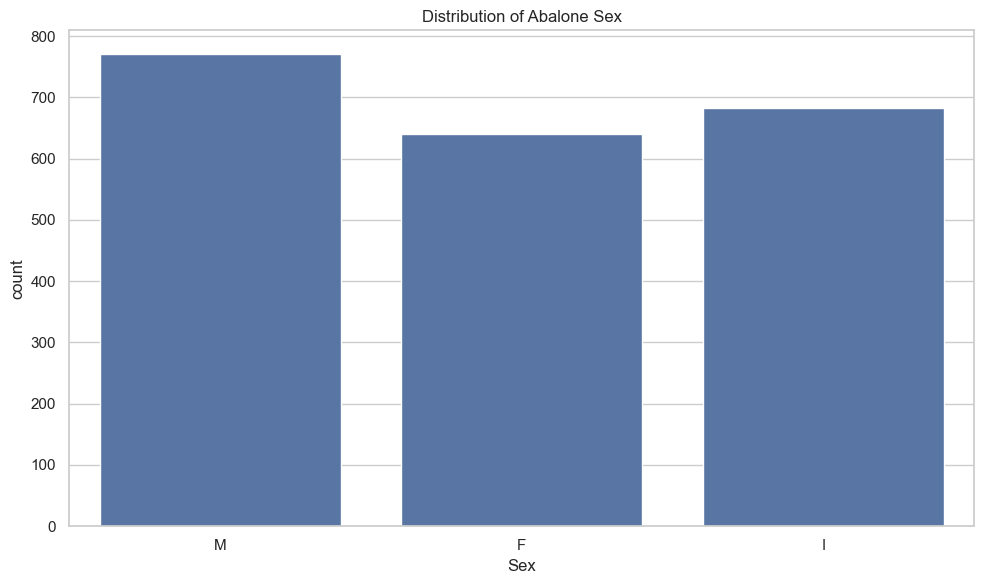

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex')
plt.title('Distribution of Abalone Sex')
save_plot('eda_sex_dist.png')
plt.show()
plt.close()


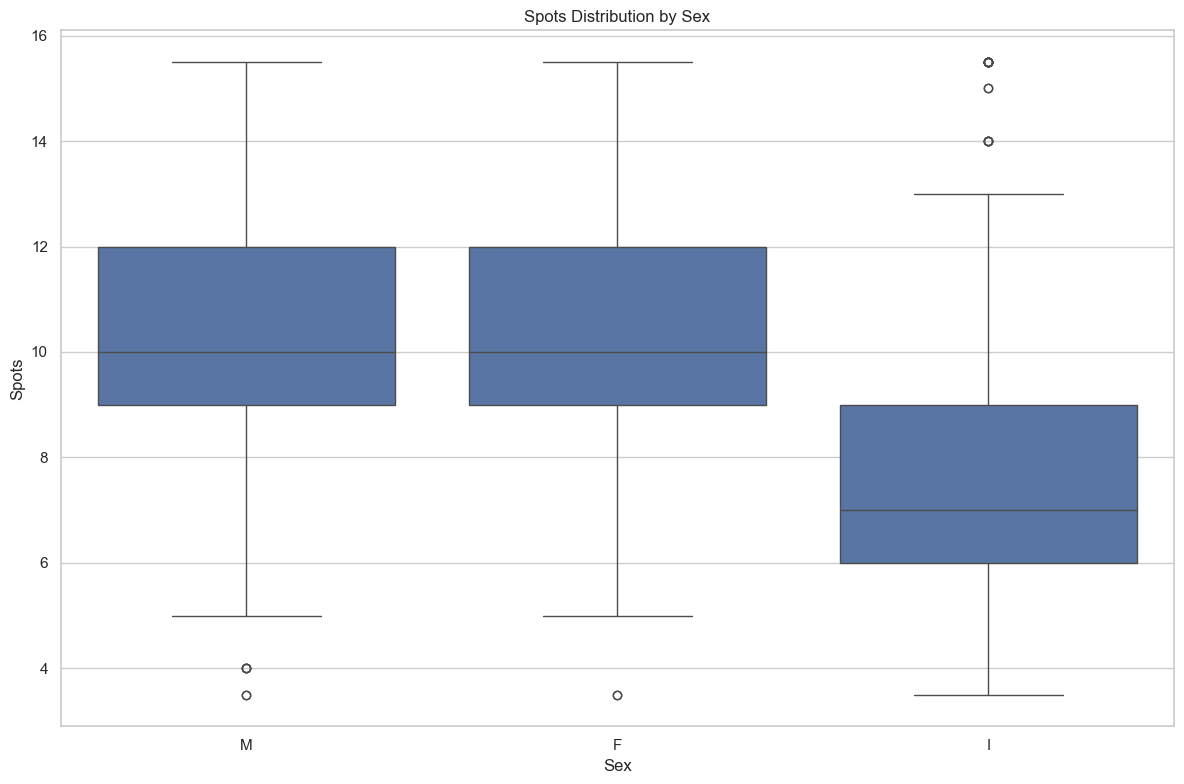

In [7]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Sex', y='Spots')
plt.title('Spots Distribution by Sex')
save_plot('eda_spots_by_sex.png')
plt.show()
plt.close()


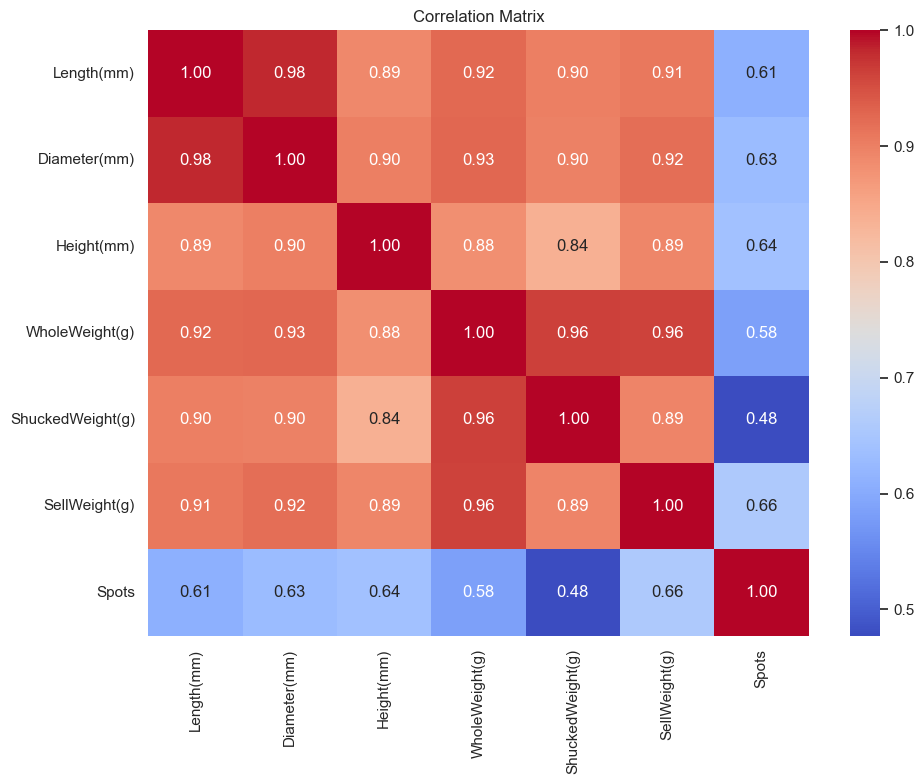

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
save_plot('eda_corr.png')
plt.show()
plt.close()


## Regression: Predicting `Spots`

In [9]:
scaler = StandardScaler()
regression_results = []
feature_tables = {}

for sex in ['M', 'F', 'I']:
    subset = df[df['Sex'] == sex]
    X = subset.drop(['Sex', 'Spots'], axis=1)
    y = subset['Spots']

    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    lasso = Lasso(alpha=0.1)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)

    regression_results.append({
        'Sex': sex,
        'R2': round(r2_score(y_test, y_pred), 4),
        'MSE': round(mean_squared_error(y_test, y_pred), 4),
    })

    importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso.coef_}).sort_values(by='Coefficient', ascending=False)
    feature_tables[sex] = importance

regression_summary = pd.DataFrame(regression_results)
regression_summary


,Sex,R2,MSE
0,M,0.4611,3.8364
1,F,0.2451,4.8205
2,I,0.4486,3.5407


In [10]:
feature_tables['M']


,Feature,Coefficient
5,SellWeight(g),2.126445
2,Height(mm),0.240503
1,Diameter(mm),0.000000
0,Length(mm),0.000000
3,WholeWeight(g),0.000000
4,ShuckedWeight(g),-1.156200


In [11]:
feature_tables['F']


,Feature,Coefficient
5,SellWeight(g),1.595308
0,Length(mm),-0.000000
1,Diameter(mm),0.000000
2,Height(mm),0.000000
3,WholeWeight(g),0.000000
4,ShuckedWeight(g),-0.960180


In [12]:
feature_tables['I']


,Feature,Coefficient
5,SellWeight(g),0.701530
2,Height(mm),0.653985
1,Diameter(mm),0.252473
0,Length(mm),0.000000
3,WholeWeight(g),0.000000
4,ShuckedWeight(g),0.000000


## Classification: Predicting `Sex`

In [13]:
le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])

X_class = df.drop(['Sex', 'Sex_encoded'], axis=1)
y_class = df['Sex_encoded']

X_class_scaled = scaler.fit_transform(X_class)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class_scaled, y_class, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_c, y_train_c)
y_pred_dt = dt.predict(X_test_c)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_c, y_train_c)
y_pred_lr = lr.predict(X_test_c)

print('Decision Tree Classification Report')
print(classification_report(y_test_c, y_pred_dt, target_names=le.classes_))
print('Logistic Regression Classification Report')
print(classification_report(y_test_c, y_pred_lr, target_names=le.classes_))


Decision Tree Classification Report
              precision    recall  f1-score   support

           F       0.22      0.06      0.09       121
           I       0.72      0.77      0.74       154
           M       0.47      0.72      0.57       144

    accuracy                           0.55       419
   macro avg       0.47      0.52      0.47       419
weighted avg       0.49      0.55      0.49       419

Logistic Regression Classification Report
              precision    recall  f1-score   support

           F       0.43      0.28      0.34       121
           I       0.73      0.75      0.74       154
           M       0.45      0.57      0.50       144

    accuracy                           0.55       419
   macro avg       0.54      0.53      0.53       419
weighted avg       0.55      0.55      0.54       419



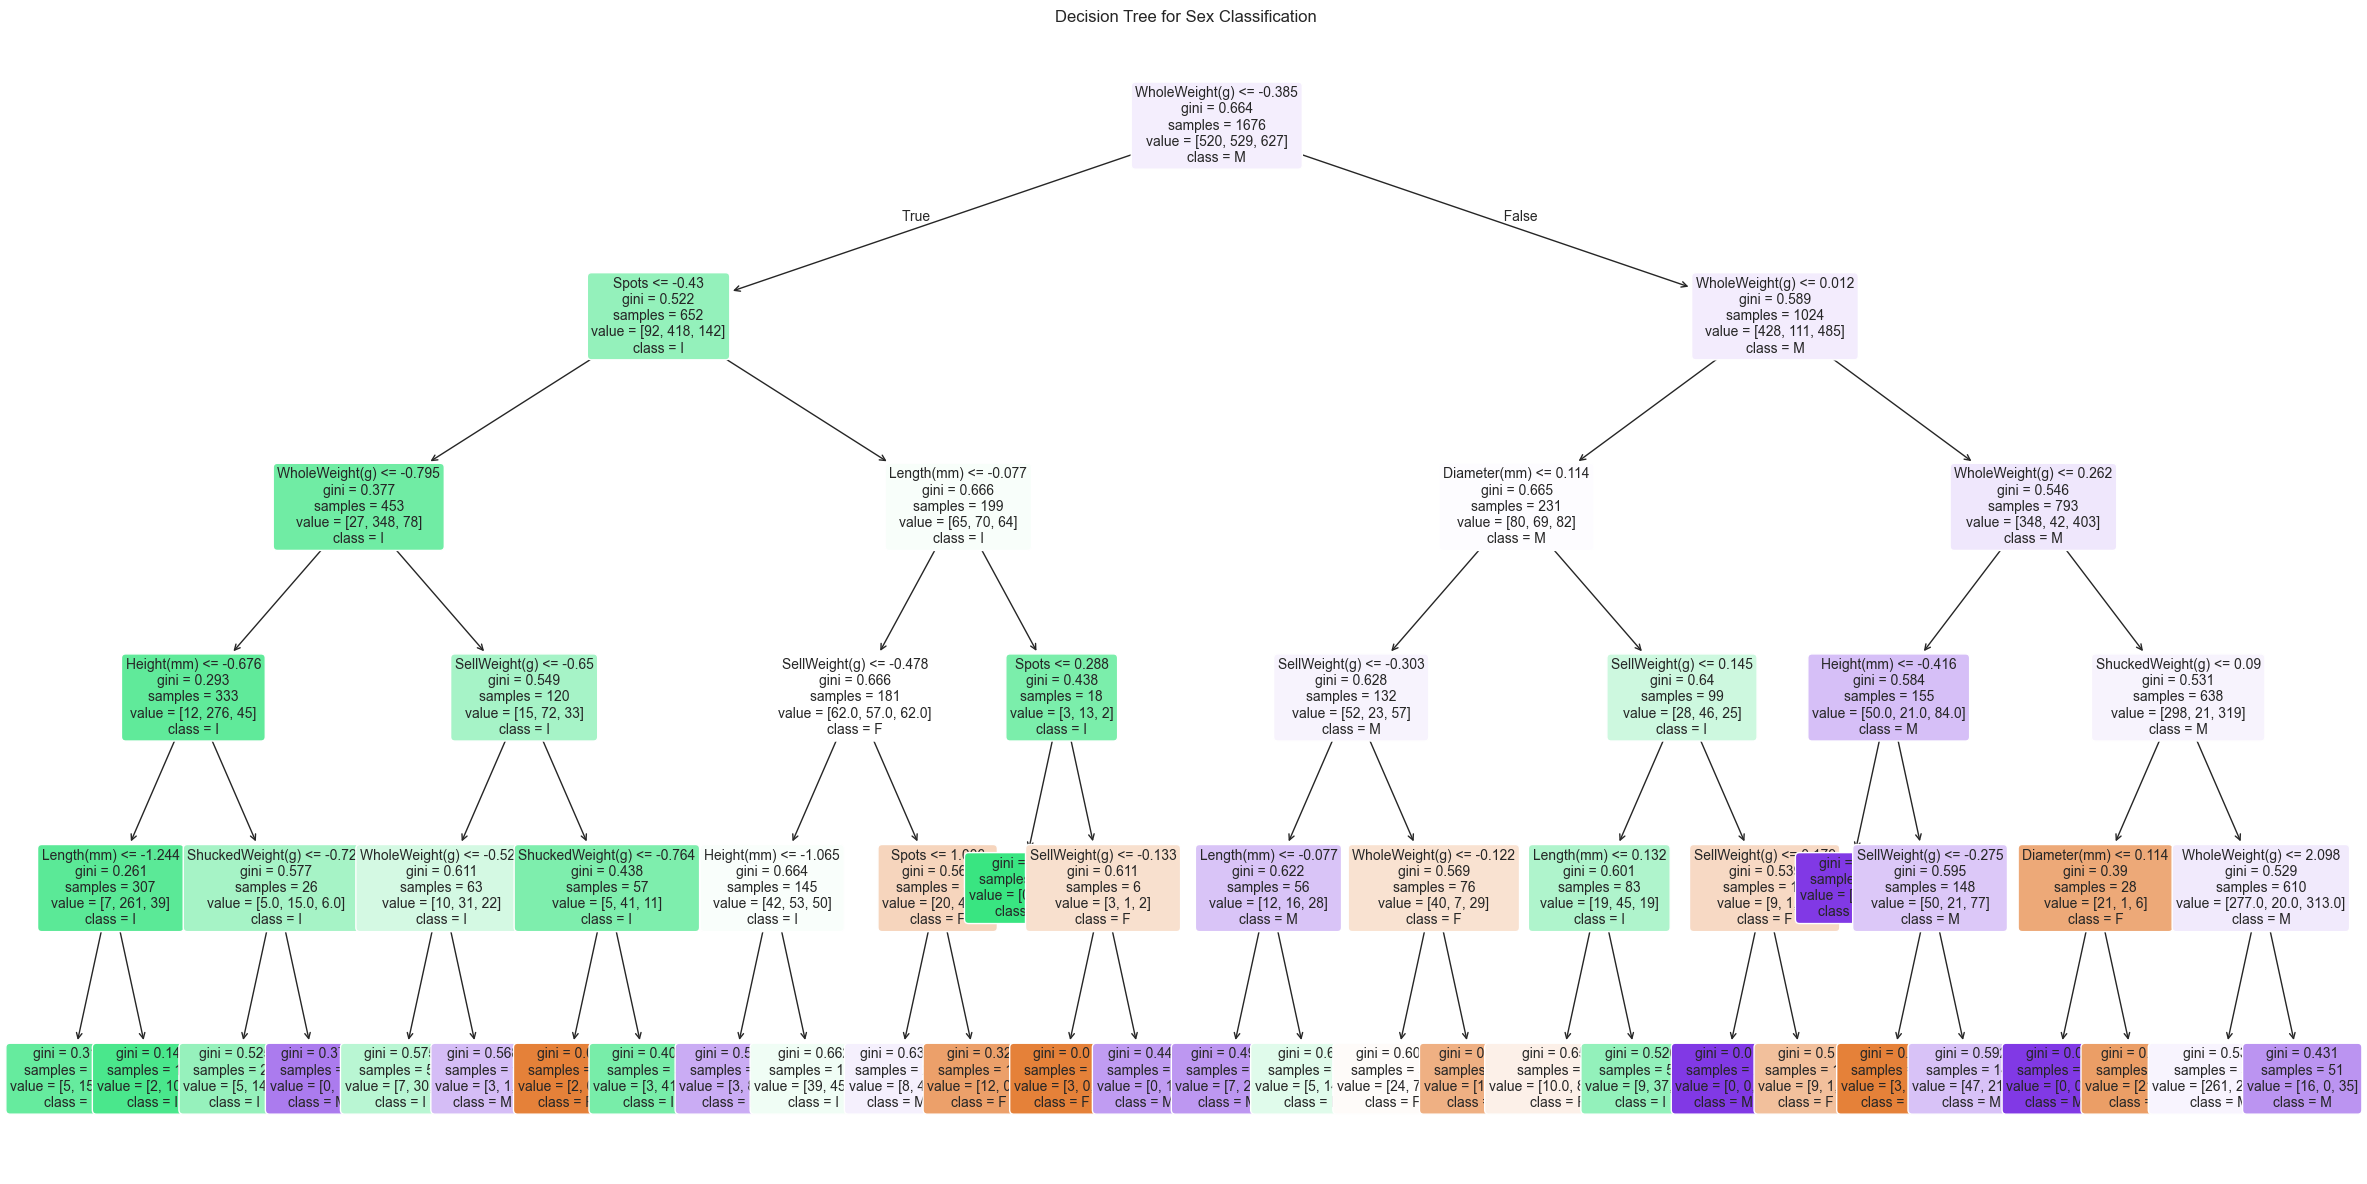

In [14]:
plt.figure(figsize=(24, 12))
plot_tree(dt, feature_names=X_class.columns, class_names=le.classes_, filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree for Sex Classification')
save_plot('decision_tree.png')
plt.show()
plt.close()


## Clustering

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_class_scaled)
cluster_sex_crosstab = pd.crosstab(df['Cluster'], df['Sex'])
cluster_sex_crosstab


Sex,F,I,M
Cluster,,,
0,291,15,308
1,57,414,110
2,293,254,353


## Summary

- The dataset starts with 2,097 rows and contains a small number of missing values in the numeric fields.
- Two invalid `Sex` values are removed during cleaning.
- `SellWeight(g)` is the strongest positive predictor of `Spots` in the LASSO regression models.
- Both classifiers reach roughly 55% accuracy, with class `I` being easier to identify than `F`.
- K-Means produces a cluster dominated by class `I`, but the remaining clusters still show strong overlap between `F` and `M`.
